# 10 — Why does sequential calibration help interval performance?
This post-hoc mechanism study uses the retained forecasts from notebook 09; it does not refit or tune models. The 90% interval score is decomposed exactly into interval width, lower-tail miss penalty, and upper-tail miss penalty. Results are then separated by asset and by information available before each forecast: trailing 20-day realized volatility. Because these hypotheses were prompted by observed regime results, they are explanatory rather than confirmatory.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.evaluation import distribution_shift_summary, summarize_components_by_state, summarize_interval_components
SOURCE = ROOT / 'results' / 'market_regimes'
OUT = ROOT / 'results' / 'interval_mechanisms'; OUT.mkdir(parents=True, exist_ok=True)
ASSETS = ['AAPL', 'JPM', 'XOM', 'WMT']

In [2]:
returns = pd.read_csv(ROOT / 'data' / 'processed' / 'financial_returns.csv', index_col=0, parse_dates=True)[ASSETS].dropna().sort_index()
PERIODS = {
    'pre_pandemic': ('2007-01-01', '2014-12-31', '2017-01-01', '2019-12-31'),
    'pandemic': ('2007-01-01', '2016-12-31', '2020-01-01', '2021-12-31'),
    'inflation_tightening': ('2007-01-01', '2019-12-31', '2022-01-01', '2023-12-31'),
    'recent': ('2007-01-01', '2021-12-31', '2024-01-01', '2025-12-31'),
}
archives = {}
for regime in PERIODS:
    archive = np.load(SOURCE / f'{regime}_forecasts.npz')
    names = [str(value) for value in archive['model_names']]
    archives[regime] = {'target': archive['target'], 'forecasts': {name: archive[f'samples_{i}'] for i, name in enumerate(names)}}
print('Loaded retained forecasts for', ', '.join(archives))

Loaded retained forecasts for pre_pandemic, pandemic, inflation_tightening, recent


## Exact score decomposition
For nominal miscoverage $\alpha=0.10$, the interval score is $W+(2/\alpha)(L-Y)\mathbf 1(Y<L)+(2/\alpha)(Y-U)\mathbf 1(Y>U)$. Hence every change is exactly the sum of a width change and changes in the two tail penalties.

In [3]:
component_rows = []
for regime, stored in archives.items():
    for model, seed_forecasts in stored['forecasts'].items():
        for seed_index, samples in enumerate(seed_forecasts):
            frame = summarize_interval_components(stored['target'], samples, ASSETS)
            frame.insert(0, 'seed_index', seed_index); frame.insert(0, 'model', model); frame.insert(0, 'regime', regime)
            component_rows.append(frame)
components = pd.concat(component_rows, ignore_index=True)
overall = components[components.asset.eq('all')]
means = overall.groupby(['regime', 'model'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage', 'predictive_sd', 'absolute_error']].mean()
display(means)
components.to_csv(OUT / 'interval_components_by_asset_seed.csv', index=False)

width  lower_penalty  \
regime               model                                        
inflation_tightening CA-RNN             2.754550       0.970758   
                     CA-RNN sequential  2.890508       0.874293   
                     RNN                2.656343       1.045221   
pandemic             CA-RNN             2.634697       1.511059   
                     CA-RNN sequential  2.758906       1.378859   
                     RNN                2.716934       1.438801   
pre_pandemic         CA-RNN             2.172322       0.507887   
                     CA-RNN sequential  2.184501       0.492107   
                     RNN                2.228438       0.468051   
recent               CA-RNN             2.297349       0.752459   
                     CA-RNN sequential  2.345776       0.719007   
                     RNN                2.364308       0.692227   

                                        upper_penalty  interval_score  \
regime               model                                              
inflation_tightening CA-RNN                  0.863294        4.588601   
                     CA-RNN sequential       0.774819        4.539620   
                     RNN                     0.884644        4.586208   
pandemic             CA-RNN                  1.665320        5.811076   
                     CA-RNN sequential       1.525115        5.662879   
                     RNN                     1.581370        5.737105   
pre_pandemic         CA-RNN                  0.428592        3.108802   
                     CA-RNN sequential       0.426108        3.102716   
                     RNN                     0.415853        3.112342   
recent               CA-RNN                  0.670226        3.720035   
                     CA-RNN sequential       0.628744        3.693527   
                     RNN                     0.608257        3.664792   

                                        coverage  predictive_sd  \
regime               model                                        
inflation_tightening CA-RNN             0.858383       0.842503   
                     CA-RNN sequential  0.876148       0.883997   
                     RNN                0.852295       0.812610   
pandemic             CA-RNN             0.801881       0.805883   
                     CA-RNN sequential  0.817723       0.843973   
                     RNN                0.814554       0.830923   
pre_pandemic         CA-RNN             0.911074       0.664424   
                     CA-RNN sequential  0.912401       0.668084   
                     RNN                0.917374       0.681548   
recent               CA-RNN             0.879980       0.701774   
                     CA-RNN sequential  0.884661       0.716679   
                     RNN                0.890837       0.722407   

                                        absolute_error  
regime               model                              
inflation_tightening CA-RNN                   0.736908  
                     CA-RNN sequential        0.734613  
                     RNN                      0.727569  
pandemic             CA-RNN                   0.861472  
                     CA-RNN sequential        0.856389  
                     RNN                      0.852558  
pre_pandemic         CA-RNN                   0.486192  
                     CA-RNN sequential        0.486171  
                     RNN                      0.484628  
recent               CA-RNN                   0.583600  
                     CA-RNN sequential        0.583743  
                     RNN                      0.579969

In [4]:
wide = overall.set_index(['regime', 'seed_index', 'model'])
rows = []
for regime in PERIODS:
    for comparator in ['RNN', 'CA-RNN']:
        candidate = wide.loc[(regime, slice(None), 'CA-RNN sequential'), :]
        baseline = wide.loc[(regime, slice(None), comparator), :]
        candidate.index = candidate.index.droplevel(['regime', 'model'])
        baseline.index = baseline.index.droplevel(['regime', 'model'])
        for metric in ['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage', 'predictive_sd', 'absolute_error']:
            difference = candidate[metric] - baseline[metric]
            rows.append({'regime': regime, 'comparison': f'sequential minus {comparator}', 'component': metric, 'mean_difference': difference.mean(), 'seed_sd': difference.std(ddof=1), 'seeds_below_zero': int((difference < 0).sum())})
differences = pd.DataFrame(rows)
display(differences[differences.comparison.eq('sequential minus RNN')].pivot(index='regime', columns='component', values='mean_difference'))
differences.to_csv(OUT / 'component_paired_differences.csv', index=False)

component,absolute_error,coverage,interval_score,lower_penalty,predictive_sd,upper_penalty,width
regime,,,,,,,
inflation_tightening,0.007044,0.023852,-0.046588,-0.170928,0.071387,-0.109824,0.234165
pandemic,0.003831,0.003168,-0.074226,-0.059942,0.013050,-0.056255,0.041972
pre_pandemic,0.001543,-0.004973,-0.009626,0.024056,-0.013464,0.010256,-0.043937
recent,0.003774,-0.006175,0.028735,0.026780,-0.005728,0.020488,-0.018533


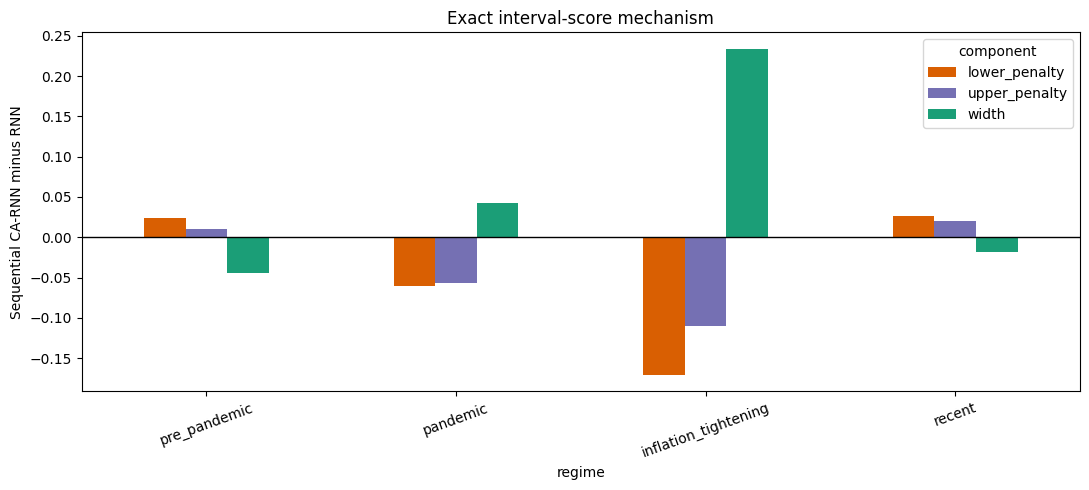

In [5]:
plot = differences[differences.comparison.eq('sequential minus RNN') & differences.component.isin(['width', 'lower_penalty', 'upper_penalty'])]
pivot = plot.pivot(index='regime', columns='component', values='mean_difference').reindex(PERIODS)
axis = pivot.plot(kind='bar', figsize=(11, 5), color=['#d95f02', '#7570b3', '#1b9e77'])
axis.axhline(0, color='black', linewidth=1); axis.set_ylabel('Sequential CA-RNN minus RNN'); axis.set_title('Exact interval-score mechanism'); axis.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(OUT / 'interval_score_decomposition.png', dpi=180, bbox_inches='tight')

## Asset and pre-forecast volatility diagnostics
Volatility states use only returns available before the target date. Terciles are defined within each test regime to retain adequate sample sizes. Conditioning on a realized market regime is descriptive and does not identify a causal mechanism.

In [6]:
asset_means = components[~components.asset.eq('all')].groupby(['regime', 'model', 'asset'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage']].mean().reset_index()
asset_pivot = asset_means.pivot(index=['regime', 'asset'], columns='model', values='interval_score')
asset_pivot['sequential_minus_RNN'] = asset_pivot['CA-RNN sequential'] - asset_pivot['RNN']
display(asset_pivot[['sequential_minus_RNN']])
asset_means.to_csv(OUT / 'asset_component_means.csv', index=False)

model                       sequential_minus_RNN
regime               asset                      
inflation_tightening AAPL              -0.005119
                     JPM                0.022068
                     WMT                0.033108
                     XOM               -0.236407
pandemic             AAPL              -0.055454
                     JPM                0.023558
                     WMT               -0.120575
                     XOM               -0.144431
pre_pandemic         AAPL              -0.038155
                     JPM               -0.016483
                     WMT                0.014478
                     XOM                0.001656
recent               AAPL               0.023990
                     JPM               -0.008843
                     WMT                0.033271
                     XOM                0.066521

In [7]:
state_rows = []
shift_rows = []
trailing_volatility = returns.rolling(20).std().mean(axis=1).shift(1)
for regime, (train_start, train_end, test_start, test_end) in PERIODS.items():
    train_values = returns.loc[train_start:train_end].to_numpy()
    test_frame = returns.loc[test_start:test_end]
    assert len(test_frame) == len(archives[regime]['target'])
    shift_rows.append({'regime': regime, **distribution_shift_summary(train_values, test_frame.to_numpy())})
    state_codes = pd.qcut(trailing_volatility.loc[test_frame.index], 3, labels=False).to_numpy()
    state = np.asarray(['low', 'medium', 'high'])[state_codes]
    for model, seed_forecasts in archives[regime]['forecasts'].items():
        for seed_index, samples in enumerate(seed_forecasts):
            frame = summarize_components_by_state(archives[regime]['target'], samples, state, ['low', 'medium', 'high'])
            frame.insert(0, 'seed_index', seed_index); frame.insert(0, 'model', model); frame.insert(0, 'regime', regime)
            state_rows.append(frame)
states = pd.concat(state_rows, ignore_index=True)
shifts = pd.DataFrame(shift_rows)
display(shifts)
display(states.groupby(['regime', 'state', 'model'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage']].mean())
states.to_csv(OUT / 'components_by_preforecast_volatility.csv', index=False)
shifts.to_csv(OUT / 'regime_shift_descriptors.csv', index=False)

,regime,mean_volatility_ratio,max_volatility_ratio,correlation_shift_frobenius,standardized_location_shift,mean_standardized_fourth_moment
0,pre_pandemic,0.692760,0.979962,0.392111,0.045541,6.103827
1,pandemic,1.260769,1.697840,0.530085,0.045150,29.874353
2,inflation_tightening,1.000215,1.289820,0.541889,0.081833,12.079110
3,recent,0.830223,1.057265,0.569400,0.102708,6.370406


width  lower_penalty  \
regime               state  model                                        
inflation_tightening high   CA-RNN             3.456708       1.159824   
                            CA-RNN sequential  3.662855       1.048393   
                            RNN                3.169248       1.383936   
                     low    CA-RNN             2.109147       0.725024   
                            CA-RNN sequential  2.178402       0.676002   
                            RNN                2.181468       0.702060   
                     medium CA-RNN             2.697795       1.027424   
                            CA-RNN sequential  2.830267       0.898484   
                            RNN                2.618313       1.049667   
pandemic             high   CA-RNN             3.651583       2.299636   
                            CA-RNN sequential  3.874842       2.066625   
                            RNN                3.729958       2.315338   
                     low    CA-RNN             2.044797       0.922514   
                            CA-RNN sequential  2.106669       0.872416   
                            RNN                2.148397       0.806076   
                     medium CA-RNN             2.211223       1.314531   
                            CA-RNN sequential  2.299089       1.200550   
                            RNN                2.275831       1.198755   
pre_pandemic         high   CA-RNN             2.602512       0.777420   
                            CA-RNN sequential  2.768019       0.694739   
                            RNN                2.735801       0.728450   
                     low    CA-RNN             1.917777       0.274185   
                            CA-RNN sequential  1.842939       0.292022   
                            RNN                1.930987       0.222994   
                     medium CA-RNN             1.995272       0.471770   
                            CA-RNN sequential  1.940609       0.489539   
                            RNN                2.016846       0.452587   
recent               high   CA-RNN             2.754925       0.876726   
                            CA-RNN sequential  2.807874       0.850226   
                            RNN                2.774859       0.878379   
                     low    CA-RNN             1.994006       0.541224   
                            CA-RNN sequential  2.040186       0.510213   
                            RNN                2.094108       0.446553   
                     medium CA-RNN             2.141259       0.840473   
                            CA-RNN sequential  2.187381       0.797516   
                            RNN                2.222267       0.752467   

                                               upper_penalty  interval_score  \
regime               state  model                                              
inflation_tightening high   CA-RNN                  1.132592        5.749125   
                            CA-RNN sequential       1.014684        5.725931   
                            RNN                     1.277218        5.830401   
                     low    CA-RNN                  0.541516        3.375687   
                            CA-RNN sequential       0.478249        3.332653   
                            RNN                     0.428202        3.311730   
                     medium CA-RNN                  0.915772        4.640992   
                            CA-RNN sequential       0.831525        4.560276   
                            RNN                     0.948511        4.616492   
pandemic             high   CA-RNN                  2.854105        8.805324   
                            CA-RNN sequential       2.586639        8.528106   
                            RNN                     2.653267        8.698563   
                     low    CA-RNN                  0.636603        3.603914   
                            CA-RNN se

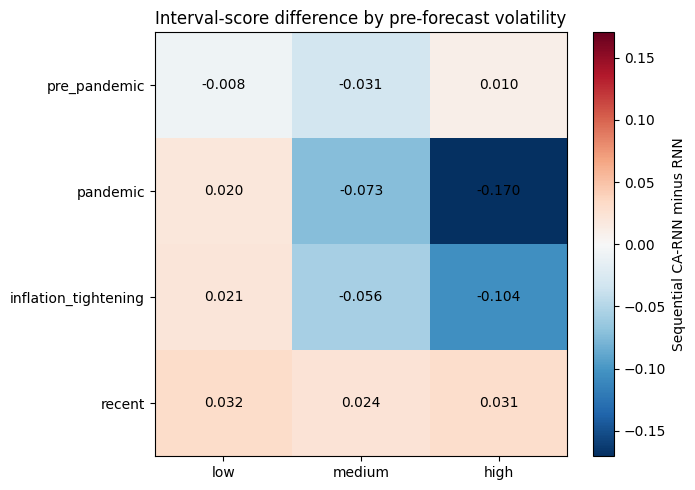

In [8]:
state_means = states.groupby(['regime', 'state', 'model'])['interval_score'].mean().unstack('model')
state_means['sequential_minus_RNN'] = state_means['CA-RNN sequential'] - state_means['RNN']
heatmap = state_means['sequential_minus_RNN'].unstack('state').reindex(index=PERIODS, columns=['low', 'medium', 'high'])
fig, axis = plt.subplots(figsize=(7, 5))
image = axis.imshow(heatmap, cmap='RdBu_r', aspect='auto', vmin=-np.abs(heatmap.to_numpy()).max(), vmax=np.abs(heatmap.to_numpy()).max())
axis.set_xticks(range(3), heatmap.columns); axis.set_yticks(range(len(heatmap)), heatmap.index); axis.set_title('Interval-score difference by pre-forecast volatility')
for i in range(len(heatmap)):
    for j in range(3): axis.text(j, i, f'{heatmap.iloc[i, j]:.3f}', ha='center', va='center')
fig.colorbar(image, ax=axis, label='Sequential CA-RNN minus RNN'); plt.tight_layout()
fig.savefig(OUT / 'volatility_state_interval_difference.png', dpi=180, bbox_inches='tight')

## Interpretation protocol
1. A lower interval score caused by a positive width difference and a larger negative tail-penalty difference indicates beneficial widening.
2. A lower score with a negative width difference indicates sharper intervals whose added misses did not outweigh their reduced width.
3. Compare lower- and upper-tail penalties to identify asymmetric failure.
4. Use the volatility-state table to determine whether an aggregate regime result is concentrated in high-volatility origins.
5. Treat all decompositions as post-hoc mechanism evidence. The exact arithmetic decomposition is factual, but the economic explanation remains a hypothesis until tested on new assets or a held-out period.